## super training

In [7]:
import os
import shutil
from run_stock_factor import StockFactor
from langchain_openai import ChatOpenAI
import json
import pandas as pd
from IPython.display import display


llm = ChatOpenAI(
  openai_api_key = os.getenv('OPENAI_API_KEY'),
  model='gpt-4o-mini',
  temperature=1,
)

def run(env, mode):
    path_out = "out_stock/GA_factor_" + env['start_date'] + "_" + env['end_date'] + "/" + env['stock_id'] + "/" 
    
    stock_factor = StockFactor(llm, env)
    stock_factor.run_factors_expand()
    train_datarange, test_datarange = stock_factor.split_expand()
    
    if mode == 0:
        out_folder = f"{path_out}ac"
    elif mode == 1:
        out_folder = f"{path_out}ev"
    if not os.path.exists(out_folder + '1'):
        if os.path.exists(out_folder):
            os.rename(out_folder, out_folder + '1')
    old_out_folder = out_folder + '1'
    old_file_result= out_folder + '1/result.json'
    with open(old_file_result, 'r') as f:
        old_res = json.load(f)
        
    df_new_result = stock_factor.run_taining(mode, train_datarange, test_datarange)
    display(df_new_result)

    if df_new_result.loc['test', 'ev'] > old_res['test']['ev']:
        print("New result is better, update the file")
        if os.path.isdir(old_out_folder):
            shutil.rmtree(old_out_folder)
        elif os.path.isfile(old_out_folder):
            os.remove(old_out_folder)
        # rename the file
        os.rename(out_folder, out_folder + '1')
    else:
        print(f"New result is not better, keep the old result, old res: {old_res['test']['ev']}, new: {df_new_result.loc['test', 'ev']}")
        # remove the directory or file safely
        if os.path.isdir(out_folder):
            shutil.rmtree(out_folder)
        elif os.path.isfile(out_folder):
            os.remove(out_folder)

env = {
    "stock_id" : "AAPL",
    "stock_name" : "Apple Inc.",
    "country" : "us",
    "start_date" : "20230401",
    "end_date" : "20240331",
}

for i in range(1000):
    run(env, 0)
    run(env, 1)

FileNotFoundError: [Errno 2] No such file or directory: 'out_stock/GA_factor_20230401_20240331/AAPL/ac1/result.json'

# 畫圖

['20240102', '20240103', '20240104', '20240105', '20240108', '20240109', '20240110', '20240111', '20240112', '20240116', '20240117', '20240118', '20240119', '20240122', '20240123', '20240124', '20240125', '20240126', '20240129', '20240130', '20240131', '20240201', '20240202', '20240205', '20240206', '20240207', '20240208', '20240209', '20240212', '20240213', '20240214', '20240215', '20240216', '20240220', '20240221', '20240222', '20240223', '20240226', '20240227', '20240228', '20240229', '20240301', '20240304', '20240305', '20240306', '20240307', '20240308', '20240311', '20240312', '20240313', '20240314', '20240315', '20240318', '20240319', '20240320', '20240321', '20240322', '20240325', '20240326', '20240327', '20240328']
[185.64, 184.25, 181.91, 181.18, 185.56, 185.14, 186.19, 185.59, 185.92, 183.63, 182.68, 188.63, 191.56, 193.89, 195.18, 194.5, 194.17, 192.42, 191.73, 188.04, 184.4, 186.86, 185.85, 187.68, 189.3, 189.41, 188.32, 188.85, 187.15, 185.04, 184.15, 183.86, 182.31, 181.5

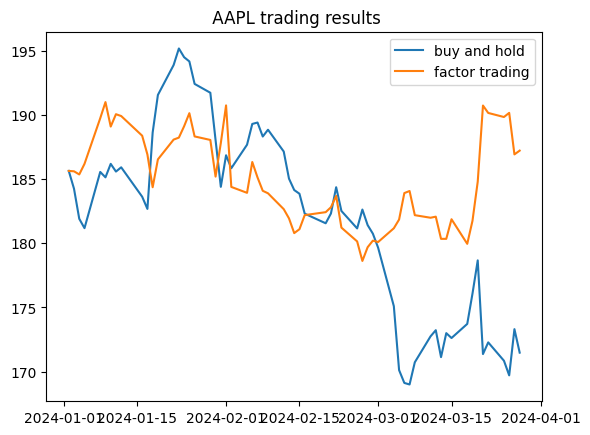

In [6]:
import matplotlib.pyplot as plt
from datetime import datetime

path_out = "out_stock/GA_factor_" + env['start_date'] + "_" + env['end_date'] + "/" + env['stock_id'] + "/" 

def remove_old_folder(old,new):
    if not os.path.exists(old):
        return
    if os.path.isdir(new):
        shutil.rmtree(new)
    elif os.path.isfile(new):
        os.remove(new)
    os.rename(old, new)
    
out_folder = f"{path_out}ac"
old_out_folder = out_folder + '1'
remove_old_folder(old_out_folder,out_folder)
    
out_folder = f"{path_out}ev"
old_out_folder = out_folder + '1'
remove_old_folder(old_out_folder,out_folder)
    
with open(f"{out_folder}/result.json", 'r') as f:
    res = json.load(f)
    res_test = res['test']

path_price_his = f"{os.path.dirname(os.path.abspath(os.getcwd()))}/history_data/{env['country']}/stock_price/{env['stock_id']}.csv"
df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')
list_bnh_rtn = []
list_factor_rtn = []
balance = df_price_his[df_price_his['Date'].dt.strftime(
    '%Y%m%d') == res_test["rtn_list"][0][0]]['Open'].values[0]
list_date = []


for date, rtn in res_test['rtn_list']:
    # print(rtn)
    balance = balance * (1 + float(rtn))
    list_date.append(date)
    list_bnh_rtn.append(df_price_his[df_price_his['Date'].dt.strftime(
        '%Y%m%d') == date]['Close'].values[0])
    list_factor_rtn.append(balance)

print(list_date)
print(list_bnh_rtn)
print(list_factor_rtn)
print(len(list_date))
print(len(list_bnh_rtn))
print(len(list_factor_rtn))

df = pd.DataFrame(list_factor_rtn, index=list_date, columns=['balance'])
dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]


plt.title(f" {env['stock_id']} trading results")
plt.plot(dplot, list_bnh_rtn, label="buy and hold")  # blue
plt.plot(dplot, list_factor_rtn, label="factor trading")  # orange
plt.legend()